### the problem is supervised for the known and unsupervised for the unknown ones

#### tokenization maybe (they are aminoacids so maybe no)
#### Dynamic padding maybe is better than standard padding
#### Evaluation metrics during the training



In [ ]:

!pip install esm
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from huggingface_hub import login
from huggingface_hub import login
from esm.models.esm3 import ESM3
from esm.sdk.api import ESM3InferenceClient, ESMProtein, GenerationConfig

# login with your Hugging Face credentials
login()



  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-42cd6eog/transformers_c989858a74964edf9b1ce3e69dca6d0f
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-42cd6eog/transformers_c989858a74964edf9b1ce3e69dca6d0f
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install ipywidgets
!pip install  esm@git+https://github.com/Biohub/esm.git@main


  Cloning https://github.com/Biohub/esm.git (to revision main) to /tmp/pip-install-olqm6lgw/esm_b1ec651dd0a2402cb329d9876533c354
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/esm.git /tmp/pip-install-olqm6lgw/esm_b1ec651dd0a2402cb329d9876533c354
  Resolved https://github.com/Biohub/esm.git to commit d96737e56af90af5f06126955d9dd670db3f930a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-olqm6lgw/transformers_890c5d44c7f24505b285369cf1c5f71e
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-olqm6lgw/transformers_890c5d44c7f24505b285369cf1c5f71e
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to

In [ ]:
!pip install esm@git+https://github.com/Biohub/esm.git@main

#!pip install git+https://github.com/huggingface/transformers.git
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer
from transformers import AutoModel, AutoTokenizer
import esm  # registers the esmc architecture with transformers

GFP = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

# optionally use "biohub/ESMC-600M" or "biohub/ESMC-300M"
model = AutoModel.from_pretrained("biohub/ESMC-300M", device_map="cuda").eval()
tokenizer = AutoTokenizer.from_pretrained("biohub/ESMC-300M")

inputs = tokenizer(GFP, return_tensors="pt", padding=True)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model(**inputs)

print(f"last_hidden_state shape: {tuple(output.last_hidden_state.shape)}")



  Cloning https://github.com/Biohub/esm.git (to revision main) to /tmp/pip-install-ae0zs422/esm_6de860dbfee5493baef2d52ab4be4a6a
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/esm.git /tmp/pip-install-ae0zs422/esm_6de860dbfee5493baef2d52ab4be4a6a
  Resolved https://github.com/Biohub/esm.git to commit d96737e56af90af5f06126955d9dd670db3f930a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Biohub/transformers.git (to revision main) to /tmp/pip-install-ae0zs422/transformers_5c9101f21931447ca9a25a3908ededbd
  Running command git clone --filter=blob:none --quiet https://github.com/Biohub/transformers.git /tmp/pip-install-ae0zs422/transformers_5c9101f21931447ca9a25a3908ededbd
  Resolved https://github.com/Biohub/transformers.git to commit ef32577f55da19a4989cd7b22e004dc43a4998cb
  Installing build dependencies ... done
  Getting requirements to

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
ESMC: transformer_engine is not installed; falling back to pure-PyTorch LayerNorm+Linear / LayerNorm+MLP. Outputs will differ numerically — measured on the unnormalized residual stream (before the final LayerNorm), ~O(10) max-diff in fp32 and ~O(100) in bf16; after the final LayerNorm these shrink to a few ULP and perplexity stays within rounding noise. Install with `pip install transformer-engine[pytorch]` to enable fused fp32-reduction LayerNorm.
ESMC: neither xformers nor fl

🚨 No checkpoint found for ESMCForSequenceClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
🚨 No checkpoint found for ESMCForTokenClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
last_hidden_state shape: (1, 240, 960)


Let s try with something smaller first (500 phrogs) till we get the compputational power

In [ ]:
import tarfile
import numpy as np
import pandas as pd
import random

random.seed(42)

annot_df = pd.read_csv("/content/phrog_annot_v4.tsv", sep="\t")
annot_map = annot_df.set_index("phrog")["annot"].to_dict()

target_phrogs = set(random.sample(range(1, 38881), 500))
PHROG_sequences = {}

with tarfile.open("/content/FAA_phrog.tar.gz") as t:
    for member in t.getmembers():
        if not member.name.endswith(".faa"):
            continue
        name = member.name.split("/")[-1]
        phrog_id = int(name.replace("phrog_", "").replace(".faa", ""))
        if phrog_id not in target_phrogs:
            continue
        f = t.extractfile(member)
        content = f.read().decode("utf-8")
        seqs = []
        for block in content.split(">")[1:]:
            lines = block.strip().split("\n")
            seq = "".join(lines[1:])
            if len(seq) > 0:
                seqs.append(seq)
        PHROG_sequences[phrog_id] = random.sample(seqs, min(100, len(seqs)))

print(f"PHROGs loaded: {len(PHROG_sequences)}")
print(f"Total sequences: {sum(len(v) for v in PHROG_sequences.values())}")

# ── SANITY CHECKS ────────────────────────────────────────────────────────────


# Labels are preserved — keys are ints, not strings
assert all(isinstance(k, int) for k in PHROG_sequences), \
    "PHROG keys should be ints — label integrity broken"
print(f"  OK: keys are ints, labels intact")

# No empty sequence lists
empty = [k for k, v in PHROG_sequences.items() if len(v) == 0]
assert len(empty) == 0, f"PHROGs with no sequences: {empty}"
print(f"  OK: no empty PHROGs")

# annot_map coverage — how many of our PHROGs have annotations?
annotated = sum(1 for pid in PHROG_sequences if pid in annot_map)
unknown_fn = sum(1 for pid in PHROG_sequences if annot_map.get(pid) == "unknown function")
print(f"  Annotation coverage: {annotated}/{len(PHROG_sequences)} PHROGs in annot_map")
print(f"  Of those, {unknown_fn} are 'unknown function' (these are your dark matter)")
# Mapping preserved after subsampling
sample_id = next(iter(PHROG_sequences))
sample_seqs = PHROG_sequences[sample_id]
print(f"  Sample PHROG {sample_id}: {len(sample_seqs)} seqs | annot: '{annot_map.get(sample_id, 'NOT IN MAP')}' | first seq[:30]: {sample_seqs[0][:30]}")
print(f"  OK: {len(PHROG_sequences)} PHROGs loaded, each with up to 100 sequences")

PHROGs loaded: 500
Total sequences: 6668
  OK: keys are ints, labels intact
  OK: no empty PHROGs
  Annotation coverage: 500/500 PHROGs in annot_map
  Of those, 0 are 'unknown function' (these are your dark matter)
  Sample PHROG 26387: 3 seqs | annot: 'ParB-like partition nuclease' | first seq[:30]: MTETSTYPRMETIPTAKLRKNAANPNEQDE
  OK: 500 PHROGs loaded, each with up to 100 sequences


In [ ]:
# Check file size first — a truncated file will be suspiciously small
import os
size = os.path.getsize("/content/FAA_phrog.tar.gz")

print(f"File size: {size / 1e6:.1f} MB")

File size: 55.5 MB


do proteins of the same function end up close together in the embedding space, even though the model was never told their function?

Attention maps in protein sequence analysis visualize how a machine learning model (usually a Transformer-based Protein Language Model) weighs the relationships between different amino acids. Interpret a sequence and predict its 3D folding and biological function

In [ ]:
from tqdm import tqdm

def embed_batch(model, tokenizer, seqs, batch_size=4):
    all_embs = []
    for i in range(0, len(seqs), batch_size):
        batch = seqs[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.inference_mode():
            output = model(**inputs)
        hidden = output.last_hidden_state
        attention_mask = inputs["attention_mask"]
        for j in range(len(batch)):
            seq_len = attention_mask[j].sum().item()
            all_embs.append(hidden[j, 1:seq_len - 1].mean(dim=0).cpu().numpy())
    return all_embs


PHROG_embeddings = {}
for phrog_id, seqs in tqdm(sorted(PHROG_sequences.items()), desc="Embedding PHROGs"):
    seq_embs = embed_batch(model, tokenizer, seqs, batch_size=4)
    PHROG_embeddings[phrog_id] = np.mean(seq_embs, axis=0)

print(f"PHROGs embedded: {len(PHROG_embeddings)}")


Embedding PHROGs: 100%|██████████| 300/300 [04:45<00:00,  1.05it/s]

PHROGs embedded: 300


In [ ]:
print(sum(len(v) for v in PHROG_sequences.values()))
print(next(model.parameters()).device)


3957
cuda:0


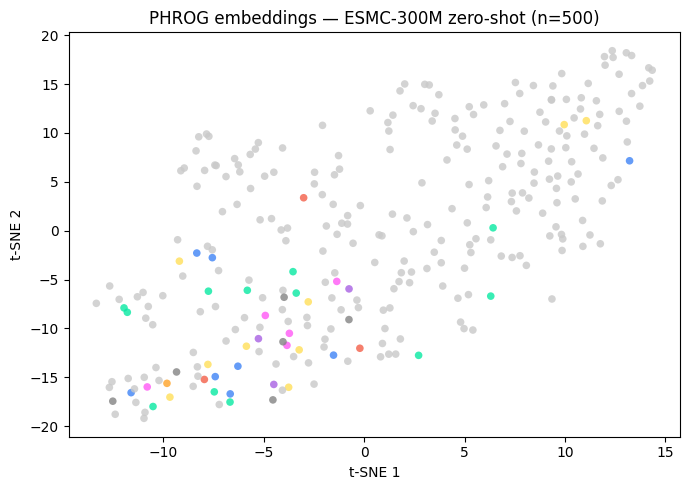

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

ids = sorted(PHROG_embeddings.keys())
X = np.array([PHROG_embeddings[i] for i in ids])

color_map = annot.set_index("phrog")["color"].to_dict()
colors = [color_map.get(i, "#aaaaaa") for i in ids]

reducer = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=30, alpha=0.8, linewidths=0)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("PHROG embeddings — ESMC-300M zero-shot (n=500)")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import random
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForMaskedLM, AutoTokenizer,AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm



r: Controls the number of trainable parameters in the LoRA adapter matrices. A higher rank increases model capacity but also memory usage.

lora_alpha = Scales the strength of the fine-tuned adjustments in relation to the rank (r)

LoRA Dropout = A regularization technique that randomly sets a fraction of LoRA activations to zero during training to prevent overfitting. Not that useful, so we default set it to 0.



In [ ]:
del model_ft
torch.cuda.empty_cache()


define the finetuned model


In [ ]:
def get_annot(pid):
    val = annot_map.get(pid, "unknown")
    if not isinstance(val, str) or val.lower() == "nan":
        return "unknown"
    return val

known_annots = sorted(set(
    get_annot(pid) for pid in PHROG_sequences
    if get_annot(pid) != "unknown"
))

annot2idx = {annot: i for i, annot in enumerate(known_annots)}
print(f"  {len(known_annots)} known annotations:")
for i, annot in enumerate(known_annots):
    print(f"    {i:2d}: {annot}")

unknown_count = sum(1 for pid in PHROG_sequences if get_annot(pid) == "unknown")
print(f"\n  {unknown_count} PHROGs with unknown annotation (dark matter)")

assert len(known_annots) > 0, "No annotated PHROGs found — check get_annot"
print(f"\n  OK: {len(known_annots)} annotations, {unknown_count} unknowns")

  55 known annotations:
     0: DNA binding protein
     1: DNA methyltransferase
     2: FtsK/SpoIIIE-like protein
     3: HNH endonuclease
     4: HicB-like antitoxin
     5: Lar-like restriction alleviation protein
     6: Nol-like carbamoyltransferase
     7: ParB-like partition nuclease
     8: RNA ligase
     9: RNA polymerase sigma factor
    10: Ren-like exclusion protein
    11: Rz-like spanin
    12: WhiB transcriptional factor
    13: amidase
    14: anti-restriction protein
    15: anti-termination protein Q-like
    16: baseplate hub assembly catalyst
    17: dehydrogenase
    18: deoxynucleoside monophosphate kinase
    19: dual specificity phosphatase
    20: endolysin
    21: glycosyltransferase
    22: head closure Hc1
    23: head maturation protease
    24: head scaffolding protein
    25: histone family DNA-binding
    26: holin
    27: homing endonuclease
    28: hydrolase
    29: internal virion lysozyme motif
    30: internal virion protein
    31: involved in ba

 ## This is a working supervised  baseline of the fine tuned model

During training, sequences from known PHROGs contribute a cross-entropy loss (predicted label vs true label). During embedding/t-SNE, you ignore the logits entirely and pull the encoder's hidden states instead

In [ ]:
!pip install -q --upgrade torchao


model_ft = AutoModelForSequenceClassification.from_pretrained(
    "biohub/ESMC-300M",
    device_map="cuda",
    torch_dtype=torch.bfloat16,
    num_labels=len(known_annots)  # your functional categories, not PHROG IDs
)

lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    lora_dropout=0.01,
    target_modules=["layernorm_qkv.1", "out_proj", "ffn.1", "ffn.3"],
)
model_ft = get_peft_model(model_ft, lora_config)
model_ft.print_trainable_parameters()

tokenizer_ft = AutoTokenizer.from_pretrained("biohub/ESMC-300M")
optimizer = AdamW(model_ft.parameters(), lr=1e-4)


Some weights of ESMCForSequenceClassification were not initialized from the model checkpoint at biohub/ESMC-300M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 234,460 || all params: 333,221,075 || trainable%: 0.0704


train test split

It loops over every PHROG, splits its sequences 80/20, and appends them to the train/val lists with the PHROG ID attached so the annotation never gets lost.

Total known PHROGs: 83
Total unknown PHROGs: 417
Unique annotations: 55

Counts per annotation:
    6  tail protein
    5  tail length tape measure protein
    4  single strand DNA binding protein
    4  virion structural protein
    3  tail fiber protein
    2  minor tail protein
    2  glycosyltransferase
    2  endolysin
    2  tail assembly chaperone
    2  RNA ligase
    2  DNA methyltransferase
    2  transposase
    2  head maturation protease
    2  terminase large subunit
    2  HNH endonuclease
    2  terminase small subunit
    1  ParB-like partition nuclease
    1  anti-restriction protein
    1  internal virion lysozyme motif
    1  long tail fiber protein distal subunit
    1  translational regulator
    1  WhiB transcriptional factor
    1  methyltransferase
    1  dehydrogenase
    1  HicB-like antitoxin
    1  deoxynucleoside monophosphate kinase
    1  Ren-like exclusion protein
    1  involved in bacteriocin production or immunity
    1  Nol-like carbamoyltransferase

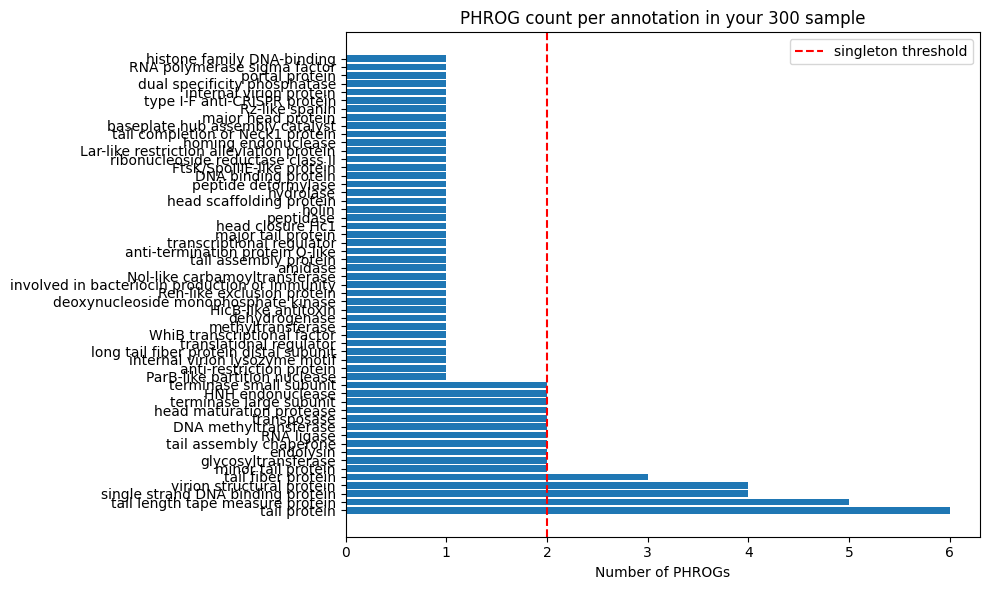

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

known_pids = [pid for pid in PHROG_sequences if get_annot(pid) != "unknown"]
annot_counts = Counter(get_annot(pid) for pid in known_pids)

print(f"Total known PHROGs: {len(known_pids)}")
print(f"Total unknown PHROGs: {len(PHROG_sequences) - len(known_pids)}")
print(f"Unique annotations: {len(annot_counts)}")
print(f"\nCounts per annotation:")
for annot, count in sorted(annot_counts.items(), key=lambda x: -x[1]):
    print(f"  {count:3d}  {annot}")

# barplot
fig, ax = plt.subplots(figsize=(10, 6))
annots, counts = zip(*sorted(annot_counts.items(), key=lambda x: -x[1]))
ax.barh(annots, counts)
ax.axvline(x=2, color="red", linestyle="--", label="singleton threshold")
ax.set_xlabel("Number of PHROGs")
ax.set_title("PHROG count per annotation in your 300 sample")
ax.legend()
plt.tight_layout()
plt.show()

For now

In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

known_pids   = [pid for pid in PHROG_sequences if get_annot(pid) != "unknown"]
unknown_pids = [pid for pid in PHROG_sequences if get_annot(pid) == "unknown"]

# drop singleton classes entirely
annot_counts    = Counter(get_annot(pid) for pid in known_pids)
splittable_pids = [pid for pid in known_pids if annot_counts[get_annot(pid)] >= 2]
dropped         = [pid for pid in known_pids if annot_counts[get_annot(pid)] < 2]

print(f"Dropped {len(dropped)} PHROGs with singleton annotations: {sorted(set(get_annot(p) for p in dropped))}")

train_pids, val_pids = train_test_split(
    splittable_pids,
    test_size=0.2,
    random_state=42
)

train_pairs = [(s, pid) for pid in train_pids + unknown_pids for s in PHROG_sequences[pid]]
val_pairs   = [(s, pid) for pid in val_pids for s in PHROG_sequences[pid]]

print(f"Train: {len(train_pairs)} seqs | {len(train_pids)} known + {len(unknown_pids)} unknown PHROGs")
print(f"Val:   {len(val_pairs)} seqs | {len(val_pids)} known PHROGs")

# ── SANITY CHECKS ────────────────────────────────────────────────────────────
assert set(train_pids).isdisjoint(set(val_pids)), "PHROG leakage"
print("  OK: no PHROG appears in both train and val")

val_annots = set(get_annot(pid) for pid in val_pids)
missing = set(get_annot(p) for p in splittable_pids) - val_annots
if missing:
    print(f"  WARNING: {len(missing)} annotations absent from val: {missing}")
else:
    print(f"  OK: {len(val_annots)} annotations represented in val")

Dropped 39 PHROGs with singleton annotations: ['DNA binding protein', 'FtsK/SpoIIIE-like protein', 'HicB-like antitoxin', 'Lar-like restriction alleviation protein', 'Nol-like carbamoyltransferase', 'ParB-like partition nuclease', 'RNA polymerase sigma factor', 'Ren-like exclusion protein', 'Rz-like spanin', 'WhiB transcriptional factor', 'amidase', 'anti-restriction protein', 'anti-termination protein Q-like', 'baseplate hub assembly catalyst', 'dehydrogenase', 'deoxynucleoside monophosphate kinase', 'dual specificity phosphatase', 'head closure Hc1', 'head scaffolding protein', 'histone family DNA-binding', 'holin', 'homing endonuclease', 'hydrolase', 'internal virion lysozyme motif', 'internal virion protein', 'involved in bacteriocin production or immunity', 'long tail fiber protein distal subunit', 'major head protein', 'major tail protein', 'methyltransferase', 'peptidase', 'peptide deformylase', 'portal protein', 'ribonucleoside reductase class II', 'tail assembly protein', 'tai

This is the correct when I get the data that I need

train-val-test has to be in the final version. **Now it is train test**

In [ ]:
# from sklearn.model_selection import train_test_split
# from collections import Counter

# known_pids   = [pid for pid in PHROG_sequences if get_annot(pid) != "unknown"]
# unknown_pids = [pid for pid in PHROG_sequences if get_annot(pid) == "unknown"]

# # drop singleton classes entirely
# annot_counts    = Counter(get_annot(pid) for pid in known_pids)
# splittable_pids = [pid for pid in known_pids if annot_counts[get_annot(pid)] >= 2]
# dropped         = [pid for pid in known_pids if annot_counts[get_annot(pid)] < 2]

# print(f"Dropped {len(dropped)} PHROGs with singleton annotations: {sorted(set(get_annot(p) for p in dropped))}")

# train_pids, val_pids = train_test_split(
#     splittable_pids,
#     test_size=0.2,
#     random_state=42,
#     stratify=[get_annot(pid) for pid in splittable_pids]
# )

# train_pairs = [(s, pid) for pid in train_pids + unknown_pids for s in PHROG_sequences[pid]]
# val_pairs   = [(s, pid) for pid in val_pids for s in PHROG_sequences[pid]]

# print(f"Train: {len(train_pairs)} seqs | {len(train_pids)} known + {len(unknown_pids)} unknown PHROGs")
# print(f"Val:   {len(val_pairs)} seqs | {len(val_pids)} known PHROGs")

# # ── SANITY CHECKS ────────────────────────────────────────────────────────────
# assert set(train_pids).isdisjoint(set(val_pids)), "PHROG leakage"
# print("  OK: no PHROG appears in both train and val")

# val_annots = set(get_annot(pid) for pid in val_pids)
# print(f"  OK: {len(val_annots)} annotations represented in val")

80 20 train test on the seq - > train on 80% of each PHROGs and the 20% are for the prediction

In [ ]:
batch_size = 1
history = {"train_loss": [], "val_loss": []}

for epoch in range(10):
    # train
    model_ft.train()
    train_loss = 0
    train_count = 0
    for seq, pid in tqdm(train_pairs, desc=f"Epoch {epoch+1} train"):
        annot = get_annot(pid)
        if annot == "unknown":
            continue  # skip unknowns — no label to train on
        label_idx = torch.tensor([annot2idx[annot]], dtype=torch.long).to("cuda")
        inputs = tokenizer_ft([seq], return_tensors="pt", padding=True, truncation=True, max_length=1024)
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        out = model_ft(**inputs, labels=label_idx)
        out.loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += out.loss.item()
        train_count += 1

    # val
    model_ft.eval()
    val_loss = 0
    val_count = 0
    with torch.inference_mode():
        for seq, pid in tqdm(val_pairs, desc=f"Epoch {epoch+1} val"):
            annot = get_annot(pid)
            if annot == "unknown":
                continue
            label_idx = torch.tensor([annot2idx[annot]], dtype=torch.long).to("cuda")
            inputs = tokenizer_ft([seq], return_tensors="pt", padding=True, truncation=True, max_length=1024)
            inputs = {k: v.to("cuda") for k, v in inputs.items()}
            out = model_ft(**inputs, labels=label_idx)
            val_loss += out.loss.item()
            val_count += 1

    avg_train = train_loss / train_count if train_count else float("nan")
    avg_val   = val_loss  / val_count   if val_count  else float("nan")
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    print(f"Epoch {epoch+1} | train loss: {avg_train:.4f} | val loss: {avg_val:.4f} | train_n: {train_count} | val_n: {val_count}")

Epoch 1 val: 100%|██████████| 219/219 [00:25<00:00,  8.52it/s]


Epoch 1 | train loss: 3.7548 | val loss: 3.1629 | train_n: 1074 | val_n: 219


Epoch 2 val: 100%|██████████| 219/219 [00:25<00:00,  8.47it/s]


Epoch 2 | train loss: 2.6560 | val loss: 3.0147 | train_n: 1074 | val_n: 219


Epoch 3 val: 100%|██████████| 219/219 [00:25<00:00,  8.48it/s]


...

Epoch 8 | train loss: 2.1192 | val loss: 2.8891 | train_n: 1074 | val_n: 219


Epoch 9 val: 100%|██████████| 219/219 [00:25<00:00,  8.56it/s]


Epoch 9 | train loss: 2.0840 | val loss: 2.9092 | train_n: 1074 | val_n: 219


Epoch 10 val: 100%|██████████| 219/219 [00:25<00:00,  8.53it/s]

Epoch 10 | train loss: 2.0479 | val loss: 2.9167 | train_n: 1074 | val_n: 219


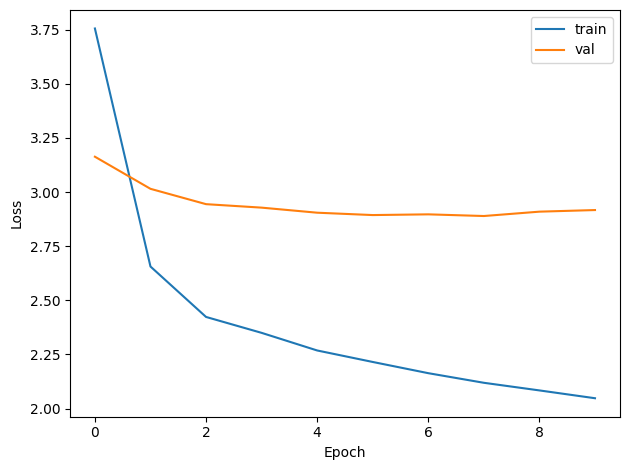

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"],   label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

Build the reverse lookup from PHROG_sequences and plot the trained model

Embedding Validation Sequences: 100%|██████████| 28/28 [00:31<00:00,  1.11s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running t-SNE reduction on 219 unseen validation sequences...


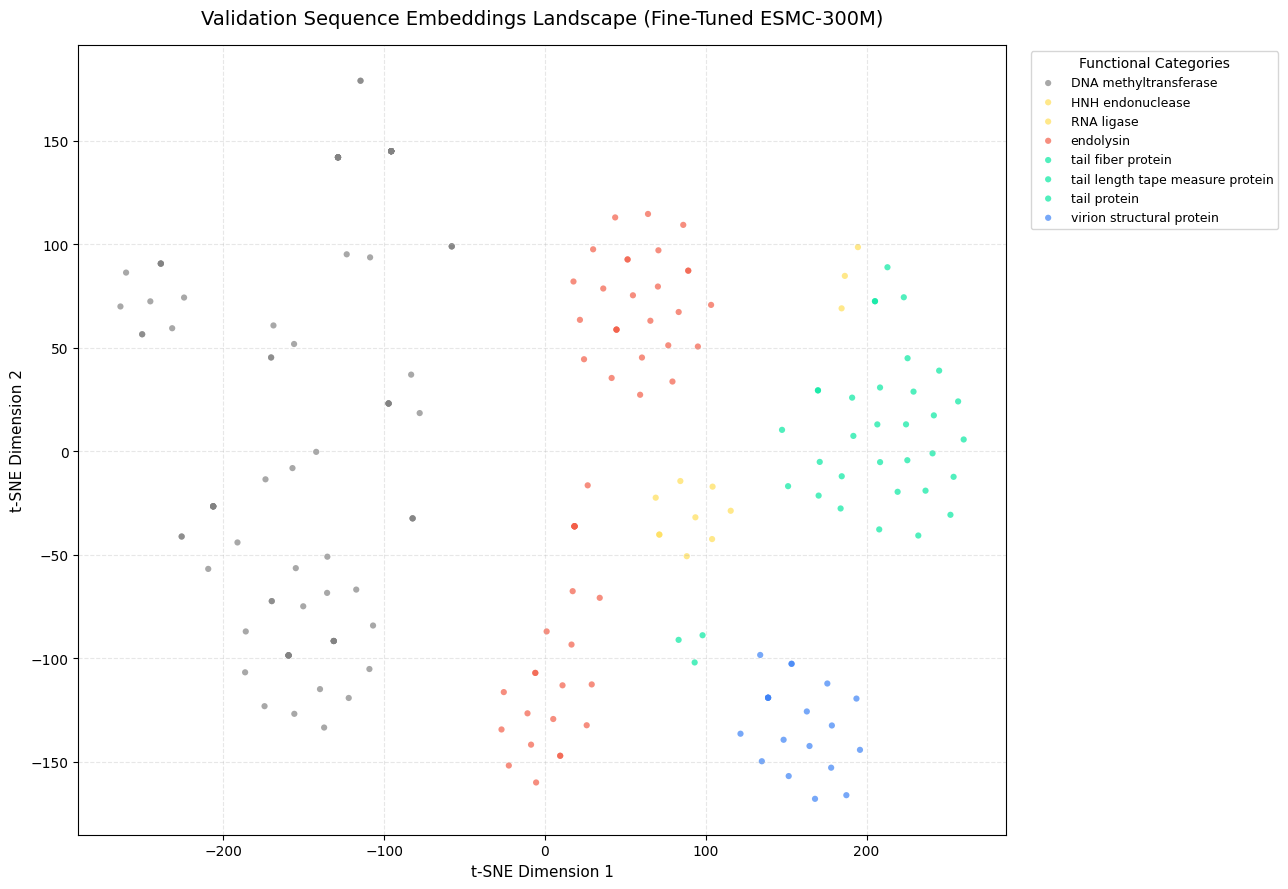

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from tqdm import tqdm
import torch

# Put model into evaluation mode
model_ft.eval()

all_sequence_embeddings = []
sequence_colors = []
sequence_labels = []

# 1. Safely pull from your freshly loaded DataFrame
# (Using annot_df to completely avoid the training loop variable collision)
color_map = annot_df.set_index("phrog")["color"].to_dict()

# 2. Extract embeddings only from the validation pairs in memory-efficient batches
batch_size = 8
for i in tqdm(range(0, len(val_pairs), batch_size), desc="Embedding Validation Sequences"):
    batch_pairs = val_pairs[i : i + batch_size]
    batch_seqs = [pair[0] for pair in batch_pairs]
    batch_pids = [pair[1] for pair in batch_pairs]

    inputs = tokenizer_ft(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024)
    inputs = {k: v.to(model_ft.device) for k, v in inputs.items()}

    with torch.inference_mode():
        output = model_ft(**inputs, output_hidden_states=True)

    hidden = output.hidden_states[-1]
    mask = inputs["attention_mask"]

    for j in range(len(batch_seqs)):
        pid = batch_pids[j]
        seq_len = mask[j].sum().item()

        # Slicing out structural special framing tokens [1:seq_len-1] and mean-pooling
        seq_emb = hidden[j, 1:seq_len - 1].mean(dim=0).cpu().float().numpy()

        all_sequence_embeddings.append(seq_emb)
        sequence_colors.append(color_map.get(pid, "#aaaaaa"))
        sequence_labels.append(get_annot(pid))

# Convert to a clean numpy array for scikit-learn
X = np.array(all_sequence_embeddings)

# 3. Compute 2D projections via t-SNE
print(f"Running t-SNE reduction on {X.shape[0]} unseen validation sequences...")
X_2d = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    n_iter=1000
).fit_transform(X)

# 4. Render the final validation landscape plot
fig, ax = plt.subplots(figsize=(13, 9))

unique_labels = sorted(list(set(sequence_labels)))
label_to_color = {}

# Map unique string labels back to their true PHROG hex colors
for lbl, color in zip(sequence_labels, sequence_colors):
    if lbl not in label_to_color:
        label_to_color[lbl] = color

# Draw point clusters grouped cleanly by functional assignment
for label in unique_labels:
    mask = [lbl == label for lbl in sequence_labels]
    ax.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=label_to_color[label],
        label=label,
        s=20,
        alpha=0.7,
        edgecolors='none'
    )

ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.set_title("Validation Sequence Embeddings Landscape (Fine-Tuned ESMC-300M)", fontsize=14, pad=15)

# Place the legend cleanly outside the box so nothing gets buried under text strings
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Functional Categories", fontsize=9, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("validation_embedding_tsne.png", dpi=300, bbox_inches="tight")
plt.show()